# Data Mining and Machine Learning Project
## Falaschi Dario - Masiero Chiara

# 1. Install & Imports

In [ ]:
!pip install -q xgboost catboost imbalanced-learn shap

In [ ]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import json
import time
import datetime
from google.colab import drive
import matplotlib.gridspec as gridspec

# Sklearn — preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Sklearn — model selection
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict,
    cross_validate
)

# Sklearn — metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)

# Boosting
from catboost import CatBoostClassifier

# Imbalanced learning
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

# SHAP
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('All libraries imported successfully.')


All libraries imported successfully.


# 2. Load Dataset

In [ ]:
# Drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/DMML_Project/online_shoppers_cleaned.csv'

# Dataset Loading
df = pd.read_csv(file_path, dtype={
    'OperatingSystems': str,
    'Browser': str,
    'Region': str,
    'TrafficType': str
})
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


#3. Define X, y, Preprocessor and SMOTENC

In [ ]:
X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (12205, 15)
y shape: (12205,)


In [ ]:
# Numerical features — scaled with StandardScaler
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Numerical column names  : {numerical_features}')

# Categorical features — encoded with OneHotEncoder
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f'Categorical column names  : {categorical_features}')

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_features)
])

print('Preprocessor defined (not yet applied)')

# SMOTENC requires integer indices of categorical columns in X
categorical_indices = [X.columns.get_loc(col) for col in categorical_features]

print(f'Categorical column indices: {categorical_indices}')

smotenc = SMOTENC(categorical_features=categorical_indices, random_state=42)
print('\nSMOTENC initialized successfully.')


Numerical column names  : ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ExitRates', 'PageValues', 'SpecialDay']
Categorical column names  : ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
Preprocessor defined (not yet applied)
Categorical column indices: [8, 9, 10, 11, 12, 13, 14]

SMOTENC initialized successfully.


# 4. Final Hyperparameter Selection on CatBoost
CatBoost was selected as the winning model based on the Nested CV results in the Notebook 2.

We now run a `GridSearchCV` on the entire dataset for the purpose of selecting the optimal hyperparameters to use in the deployment model.


In [ ]:
final_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

final_pipeline = ImbPipeline(steps=[
    ('smotenc', smotenc),
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        eval_metric='Logloss',
        random_state=42,
        verbose=0
    ))
])

final_param_grid = {
      'classifier__iterations': [100, 200],
      'classifier__learning_rate': [0.01, 0.05],
      'classifier__depth': [3, 5],
}

print('Running final GridSearchCV on CatBoost...')

start = time.time()

final_search = GridSearchCV( estimator=final_pipeline, param_grid=final_param_grid, cv=final_cv,
                            scoring='f1', n_jobs=-1, verbose=1, refit=True)

final_search.fit(X, y)

elapsed = time.time() - start
print(f'\nCompleted in {elapsed:.0f}s ({elapsed/60:.1f} min)')
print(f'\nBest parameters:')
for param, value in final_search.best_params_.items():
    print(f'  {param}: {value}')

Running final GridSearchCV on CatBoost...
Fitting 10 folds for each of 8 candidates, totalling 80 fits

Completed in 243s (4.1 min)

Best parameters:
  classifier__depth: 5
  classifier__iterations: 200
  classifier__learning_rate: 0.01


# 5. Final Model Training

We retrain CatBoost from scratch on the entire dataset
using the optimal hyperparameters found by GridSearchCV.

In [ ]:
# Extract best hyperparameters
best_params = {
    k.replace('classifier__', ''): v
    for k, v in final_search.best_params_.items()
}
print(f'Best hyperparameters: {best_params}')

# Build final pipeline with best params
final_model = ImbPipeline(steps=[
    ('smotenc',      smotenc),
    ('preprocessor', preprocessor),
    ('classifier',   CatBoostClassifier(**best_params, eval_metric='Logloss',
                                        random_state=42, verbose=0))
])

final_model.fit(X, y)
print('Final model trained successfully.')

# Save model to Drive
model_path = '/content/drive/MyDrive/DMML_Project/catboost_final_model.pkl'
joblib.dump(final_model, model_path)
print(f'Model saved')

Best hyperparameters: {'depth': 5, 'iterations': 200, 'learning_rate': 0.01}
Final model trained successfully.
Model saved


# 6. Feature Importance

We extract the feature importance from the trained Catboost classifier.
Feature importance measures how much each feature contributes to the model's decisions. We visualise the features ranked by importance score.


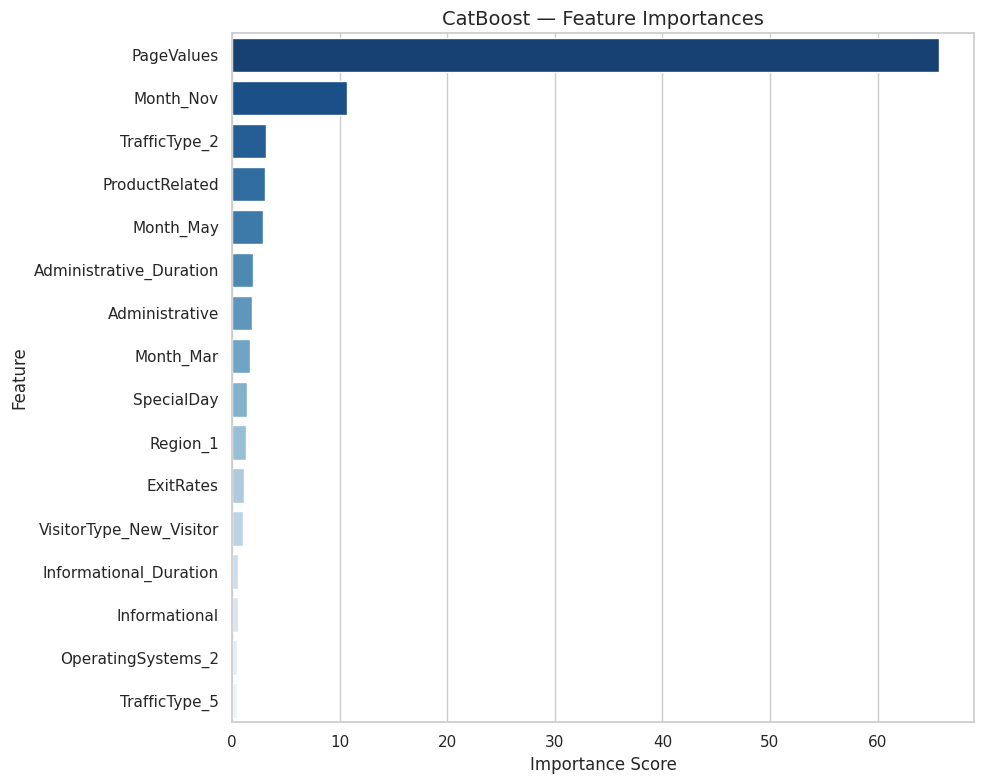

Plot saved.


In [ ]:
# Get feature names after preprocessing
ohe_features = final_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(ohe_features)

# Extract feature importance from CatBoost
catboost_classifier = final_model.named_steps['classifier']
importances = catboost_classifier.feature_importances_

# Create DataFrame and sort
fi_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(16)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=fi_df,
    x='Importance', y='Feature',
    palette='Blues_r'
)
plt.title('CatBoost — Feature Importances', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DMML_Project/feature_importance_catboost.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')



#7. Ablation Study — Removing Google Analytics Features

Since `PageValues` emerged as the dominant feature in the CatBoost feature importance analysis, we investigated its nature more carefully. In doing so, we realised that `PageValues` is a metric provided by **Google Analytics** within the variables `BounceRates` and `ExitRates` .

This matters because Google Analytics computes these metrics through proprietary aggregation logic that is not fully documented. Using opaque derived variables of this kind risks building a model that relies on a proxy for the label rather than on real purchasing behaviour, which is a form of **indirect target leakage**.

We therefore decided to remove all Google Analytics variables from the feature set, in order for us to assess if the model can still learn meaningful purchasing patterns from the remaining features.

`BounceRates` was already eliminated in Notebook 1 due to its correlation with `ExitRates`. We now remove the two remaining ones: **`PageValues`** and **`ExitRates`**.


## 7.1 Define Features and Preprocessor
We redefine the feature lists and build a new `ColumnTransformer` and `SMOTENC`
instance that operate on `X_noGA`

The **categorical feature indices** must be recomputed on `X_noGA`
since removing a numerical column shifts the positional indices of the
categorical columns.

In [ ]:
# Remove all Google Analytics features
X_noGA = X.drop(columns=["PageValues", "ExitRates"])
y_noGA = y.copy()

print("Original X shape:              ", X.shape)
print("X without GA features shape:   ", X_noGA.shape)

Original X shape:               (12205, 15)
X without GA features shape:    (12205, 13)


In [ ]:
# Numerical features — scaled with StandardScaler
numerical_features_noGA = X_noGA.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Numerical column names  : {numerical_features_noGA}')

# Categorical features — encoded with OneHotEncoder
categorical_features_noGA = X_noGA.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f'Categorical column names  : {categorical_features_noGA}')

preprocessor_noGA = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features_noGA),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_features_noGA)
])

print('Preprocessor defined (not yet applied)')

# SMOTENC
categorical_indices_noGA = [X_noGA.columns.get_loc(col) for col in categorical_features_noGA]
smotenc_noGA = SMOTENC(categorical_features=categorical_indices_noGA, random_state=42)

print('Preprocessor and SMOTENC defined for experiment without Google Analytics features.')

Numerical column names  : ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'SpecialDay']
Categorical column names  : ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
Preprocessor defined (not yet applied)
Preprocessor and SMOTENC defined for experiment without Google Analytics features.


##7.2 NestedCV Without GA
We run the same `NestedCV` grid used for the full model

In [ ]:
SCORING_METRICS = ['accuracy', 'precision', 'recall', 'f1']

# Same fold structure as NB2, 10x10 Nested CV to keep results comparable
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

catboost_model = CatBoostClassifier(random_state=42, verbose=0)

# Same hyperparameter grid as NB2 for a fair comparison
catboost_param_grid = {
      'classifier__iterations': [100, 200],
      'classifier__learning_rate': [0.01, 0.05],
      'classifier__depth': [3, 5],
}

# Pipeline rebuilt from scratch on X_noGA
pipeline_noGA = ImbPipeline(steps=[
    ('smotenc', smotenc_noGA),
    ('preprocessor', preprocessor_noGA),
    ('classifier', catboost_model)
])

# Inner loop: GridSearchCV selects the best hyperparameters on each training fold
inner_search_noGA = GridSearchCV(estimator=pipeline_noGA, param_grid=catboost_param_grid, cv=inner_cv,
                                 scoring='f1', n_jobs=-1, refit=True)

# Outer loop: cross_validate produces one unbiased F1 estimate per outer fold.
cv_results_noGA = cross_validate( estimator=inner_search_noGA, X=X_noGA, y=y_noGA, cv=outer_cv,
                                 scoring=SCORING_METRICS, n_jobs=-1, return_estimator=True)

print('\nCatBoost WITHOUT Google Analytics features — best params per outer fold:')
for fold_i, estimator in enumerate(cv_results_noGA['estimator']):
    print(f'  Fold {fold_i+1}: {estimator.best_params_}')

print('\nCatBoost WITHOUT Google Analytics features — Nested CV results:')
print(f'Accuracy : {cv_results_noGA["test_accuracy"].mean():.4f} ± {cv_results_noGA["test_accuracy"].std():.4f}')
print(f'Precision: {cv_results_noGA["test_precision"].mean():.4f} ± {cv_results_noGA["test_precision"].std():.4f}')
print(f'Recall   : {cv_results_noGA["test_recall"].mean():.4f} ± {cv_results_noGA["test_recall"].std():.4f}')
print(f'F1-score : {cv_results_noGA["test_f1"].mean():.4f} ± {cv_results_noGA["test_f1"].std():.4f}')

print('\nAll CatBoost nested CV runs without Google Analytics features completed!')


CatBoost WITHOUT Google Analytics features — best params per outer fold:
  Fold 1: {'classifier__depth': 3, 'classifier__iterations': 100, 'classifier__learning_rate': 0.05}
  Fold 2: {'classifier__depth': 3, 'classifier__iterations': 200, 'classifier__learning_rate': 0.05}
  Fold 3: {'classifier__depth': 5, 'classifier__iterations': 100, 'classifier__learning_rate': 0.05}
  Fold 4: {'classifier__depth': 3, 'classifier__iterations': 200, 'classifier__learning_rate': 0.05}
  Fold 5: {'classifier__depth': 5, 'classifier__iterations': 100, 'classifier__learning_rate': 0.05}
  Fold 6: {'classifier__depth': 5, 'classifier__iterations': 200, 'classifier__learning_rate': 0.01}
  Fold 7: {'classifier__depth': 3, 'classifier__iterations': 100, 'classifier__learning_rate': 0.05}
  Fold 8: {'classifier__depth': 3, 'classifier__iterations': 200, 'classifier__learning_rate': 0.05}
  Fold 9: {'classifier__depth': 3, 'classifier__iterations': 200, 'classifier__learning_rate': 0.05}
  Fold 10: {'clas

## 7.3 Comparison: With GA vs Without GA

We now compare the two models side by side across the main evaluation metrics.
The goal is to quantify the performance cost of removing `PageValues` and `ExitRates`  and determine if the remaining features alone are sufficient for a meaningful classifier.


=== CatBoost Comparison: With vs Without Google Analytics Features ===
                     Accuracy  Precision (Purchase)  Recall (Purchase)  F1 (Purchase)
With GA features       0.8785                0.5819             0.7977         0.6726
Without GA features    0.7186                0.2859             0.5346         0.3723


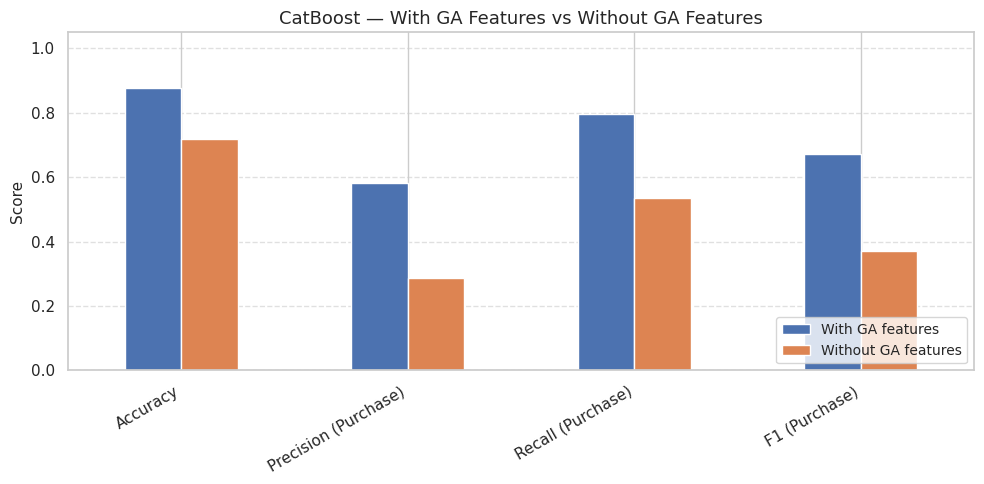

Comparison plot saved.


In [ ]:
# Load results from JSON checkpoint
nested_cv_checkpoint_path = '/content/drive/MyDrive/DMML_Project/nested_cv_checkpoint.json'

with open(nested_cv_checkpoint_path, 'r') as f:
    nested_cv_results = json.load(f)

model_name = 'CatBoost'

# CatBoost WITH all features (full model)
catboost_full = {
    'Accuracy':             pd.Series(nested_cv_results['accuracy'][model_name]).mean(),
    'Precision (Purchase)': pd.Series(nested_cv_results['precision'][model_name]).mean(),
    'Recall (Purchase)':    pd.Series(nested_cv_results['recall'][model_name]).mean(),
    'F1 (Purchase)':        pd.Series(nested_cv_results['f1'][model_name]).mean(),
}

# CatBoost WITHOUT Google Analytics features
catboost_noGA = {
    'Accuracy':             cv_results_noGA['test_accuracy'].mean(),
    'Precision (Purchase)': cv_results_noGA['test_precision'].mean(),
    'Recall (Purchase)':    cv_results_noGA['test_recall'].mean(),
    'F1 (Purchase)':        cv_results_noGA['test_f1'].mean(),
}

# Comparison table
df_comparison = pd.DataFrame(
    [catboost_full, catboost_noGA],
    index=['With GA features', 'Without GA features']
)

print('\n=== CatBoost Comparison: With vs Without Google Analytics Features ===')
print(df_comparison.round(4).to_string())

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))

df_comparison.T.plot(
    kind='bar',
    ax=ax,
    edgecolor='white'
)

ax.set_title('CatBoost — With GA Features vs Without GA Features', fontsize=13)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/DMML_Project/catboost_comparison_GA.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Comparison plot saved.')

### 7.3b Comparison: With GA Features vs Without GA Features

The table and bar chart above compare the two CatBoost models across all evaluation metrics.
Removing `PageValues` and `ExitRates` causes a substantial drop across every metric. F1 falls from **0.67 to 0.37** (−45%), Precision from **0.58 to 0.29** (−51%), and Recall from **0.80 to 0.53** (−33%).

Removing GA features hurts precision much more than recall: the no-GA model still finds about half of actual buyers (53% Recall), but generates far more false alarms — only 1 in 3 predicted purchases is real. This suggests that PageValues is not what finds buyers, but what filters out non-buyers who look similar behaviorally.
That said, the model is not just guessing. An F1 of 0.37 on a dataset where only 15.6% of sessions end in a purchase is above random — browsing behaviour, seasonality, and traffic source still carry real signal. This is why running SHAP on the no-GA model makes sense: the model is still making interpretable decisions, just without the shortcut that GA features provide.

## 7.4 Train/Test Split and Final Model Training

The Nested Cross-Validation provides the unbiased estimate of the model's generalization performance used for model comparison.

We instantiated a final model using a standard Train/Test Holdout split. The purpose of this Holdout is to retain a subset of test instances to compute reliable local SHAP explanations without evaluating samples the model had seen during its specific training phase.

We split `X_noGA` into a training set (70%) and a held-out test set (30%).
The final model is trained **only on `X_train_noGA`** so that `X_test_noGA`
is genuinely unseen — this test set will be used in Section 8 to select
representative samples for the local SHAP analysis.

The hyperparameters are taken from the best params most frequently selected
by the inner GridSearchCV across the outer folds of the Nested CV (Section 7.2).

In [ ]:
# Train/test split — stratified to preserve class imbalance.
from sklearn.model_selection import train_test_split

X_train_noGA, X_test_noGA, y_train_noGA, y_test_noGA = train_test_split(
    X_noGA, y_noGA, test_size=0.30, random_state=42,
  stratify=y_noGA
)

print(f'Train size : {X_train_noGA.shape[0]} samples')
print(f'Test  size : {X_test_noGA.shape[0]} samples')
print(f'\nClass distribution — train:')
print(y_train_noGA.value_counts(normalize=True).round(3).to_string())
print(f'\nClass distribution — test:')
print(y_test_noGA.value_counts(normalize=True).round(3).to_string())

# --- GridSearch for hyperparameter selection (on train only) ---
# GridSearchCV clones pipeline_noGA internally on each fold,
# so the fitted state from cross_validate above has no effect.
final_cv_noGA = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

final_search_noGA = GridSearchCV( estimator=pipeline_noGA, param_grid=catboost_param_grid, cv=final_cv_noGA,
                                 scoring='f1', n_jobs=-1, refit=True)

print('\nRunning GridSearch for hyperparameter selection (train set only)...')
start = time.time()
final_search_noGA.fit(X_train_noGA, y_train_noGA)
elapsed = time.time() - start
print(f'Completed in {elapsed:.0f}s ({elapsed/60:.1f} min)')
print(f'Best parameters: {final_search_noGA.best_params_}')

# --- Extract best hyperparameters ---
best_params_noGA = {
    k.replace('classifier__', ''): v
    for k, v in final_search_noGA.best_params_.items()
}

# --- Build and train final model on X_train_noGA only ---
final_model_noGA = ImbPipeline(steps=[
    ('smotenc',      SMOTENC(categorical_features=categorical_indices_noGA, random_state=42)),
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features_noGA),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_features_noGA)
    ])),
    ('classifier',   CatBoostClassifier(**best_params_noGA,eval_metric='Logloss',
                                        random_state=42,verbose=0
    ))
])

final_model_noGA.fit(X_train_noGA, y_train_noGA)
print('\nFinal model trained on X_train_noGA successfully.')

# Save
model_path_noGA = '/content/drive/MyDrive/DMML_Project/catboost_final_model_noGA.pkl'
joblib.dump(final_model_noGA, model_path_noGA)
print(f'Model saved: {model_path_noGA}')


Train size : 8543 samples
Test  size : 3662 samples

Class distribution — train:
Revenue
0    0.844
1    0.156

Class distribution — test:
Revenue
0    0.844
1    0.156

Running GridSearch for hyperparameter selection (train set only)...
Completed in 140s (2.3 min)
Best parameters: {'classifier__depth': 5, 'classifier__iterations': 200, 'classifier__learning_rate': 0.01}

Final model trained on X_train_noGA successfully.
Model saved: /content/drive/MyDrive/DMML_Project/catboost_final_model_noGA.pkl


##7.5 Model Evaluation on Held-out Test Set (no-GA model)

              precision    recall  f1-score   support

 No Purchase     0.9015    0.7466    0.8168      3090
    Purchase     0.2901    0.5594    0.3821       572

    accuracy                         0.7174      3662
   macro avg     0.5958    0.6530    0.5994      3662
weighted avg     0.8060    0.7174    0.7489      3662



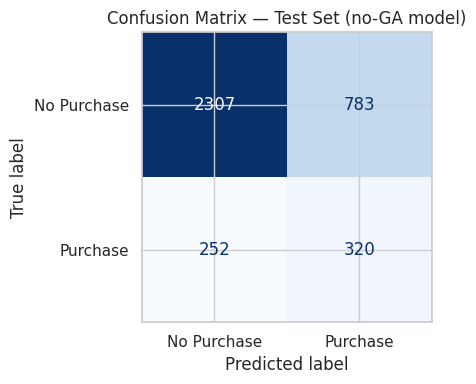

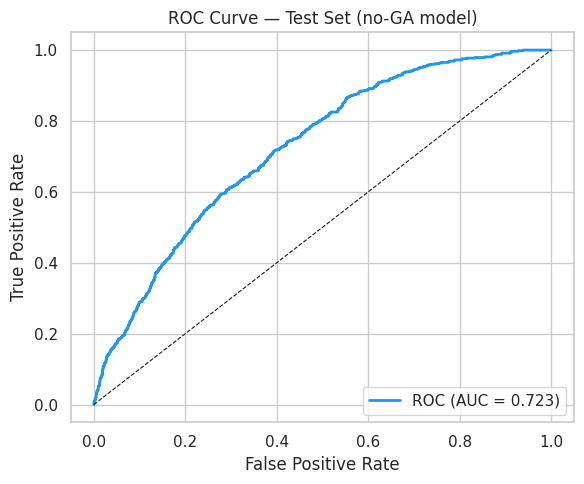

Test ROC-AUC: 0.7232


In [ ]:
y_pred_test  = final_model_noGA.predict(X_test_noGA)
y_proba_test = final_model_noGA.predict_proba(X_test_noGA)[:, 1]

# Report testuale: precision, recall, f1 per classe
print(classification_report(y_test_noGA, y_pred_test,
                            target_names=['No Purchase', 'Purchase'], digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test_noGA, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['No Purchase', 'Purchase']).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Confusion Matrix — Test Set (no-GA model)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DMML_Project/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test_noGA, y_proba_test)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#2196F3', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Test Set (no-GA model)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DMML_Project/roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Test ROC-AUC: {roc_auc:.4f}')

# 8. SHAP Analysis

**SHAP** provides model explanations by attributing each prediction to individual features.

All SHAP analysis is performed on the model **without Google Analytics features** to obtain explanations that reflect the real behavioural of the data.
The analysis is structured in two layers:

- **Global explanation** (8.1): which features matter most across the entire dataset and in which direction (Beeswarm + Bar plots).
- **Local explanation** (8.2): how the model arrived at a single prediction, on representative samples (True Positive, False Negative) by Waterfall plots.


In [ ]:
# Build feature names after preprocessing
preprocessor_fitted_noGA = final_model_noGA.named_steps['preprocessor']

ohe_noGA = preprocessor_fitted_noGA.named_transformers_['cat']
ohe_features_noGA = ohe_noGA.get_feature_names_out(categorical_features_noGA)
feature_names_noGA = numerical_features_noGA + list(ohe_features_noGA)

print(f'Total features without Google Analytics features: {len(feature_names_noGA)}')
print(feature_names_noGA)

Total features without Google Analytics features: 69
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'SpecialDay', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3', 'OperatingSystems_4', 'OperatingSystems_5', 'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8', 'Browser_1', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13', 'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7', 'Browser_8', 'Browser_9', 'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6', 'Region_7', 'Region_8', 'Region_9', 'TrafficType_1', 'TrafficType_10', 'TrafficType_11', 'TrafficType_13', 'TrafficType_14', 'TrafficType_15', 'TrafficType_16', 'TrafficType_17', 'TrafficType_18', 'TrafficType_19', 'TrafficType_2', 'TrafficType_20', 'TrafficType_3', 'Traffi

In [ ]:
# --- Preprocess train set — background for TreeExplainer and global plots ---
X_train_transformed = preprocessor_fitted_noGA.transform(X_train_noGA)
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()
X_shap_train = pd.DataFrame(X_train_transformed, columns=feature_names_noGA)

# --- Preprocess test set — for local waterfall plots ---
X_test_transformed = preprocessor_fitted_noGA.transform(X_test_noGA)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()
X_shap_test = pd.DataFrame(X_test_transformed, columns=feature_names_noGA)

explainer_noGA = shap.TreeExplainer(
    final_model_noGA.named_steps['classifier'],
    data=shap.maskers.Independent(X_shap_train, max_samples=X_shap_train.shape[0]),
    feature_perturbation='interventional',
    model_output='probability' # SHAP values on probability scale
)

# Binary classification → Explanation object is 2D (samples × features)
shap_obj_train = explainer_noGA(X_shap_train, check_additivity=False)
shap_obj_test  = explainer_noGA(X_shap_test,  check_additivity=False)

print(f'X_shap_train shape             : {X_shap_train.shape}')
print(f'X_shap_test shape              : {X_shap_test.shape}')
print(f'SHAP object (train) shape      : {shap_obj_train.shape}')
print(f'SHAP object (test)  shape      : {shap_obj_test.shape}')
print(f'Baseline E[f(X)]               : {explainer_noGA.expected_value:.4f}') #average predicted purchase probability over training set

100%|===================| 3661/3662 [56:45<00:00]       

X_shap_train shape             : (8543, 69)
X_shap_test shape              : (3662, 69)
SHAP object (train) shape      : (8543, 69)
SHAP object (test)  shape      : (3662, 69)
Baseline E[f(X)]               : 0.3985


**Important note on SHAP Baseline:**
The expected value E[f(X)] = 0.3985 represents the average purchase probability predicted by the model on the background dataset.

This value is higher than the natural dataset distribution (15.5%) due to the calibration shift introduced by the SMOTENC oversampling technique during training.

## 8.1 Global SHAP — Beeswarm and Bar Plots

- The **beeswarm plot** shows the distribution of SHAP values for each feature across all samples. Each dot is a sample; the colour encodes the feature value (red = high, blue = low), and the horizontal position encodes the SHAP contribution (right = pushes towards purchase, left = pushes away from purchase). This reveals both *importance* and *direction* of effect.

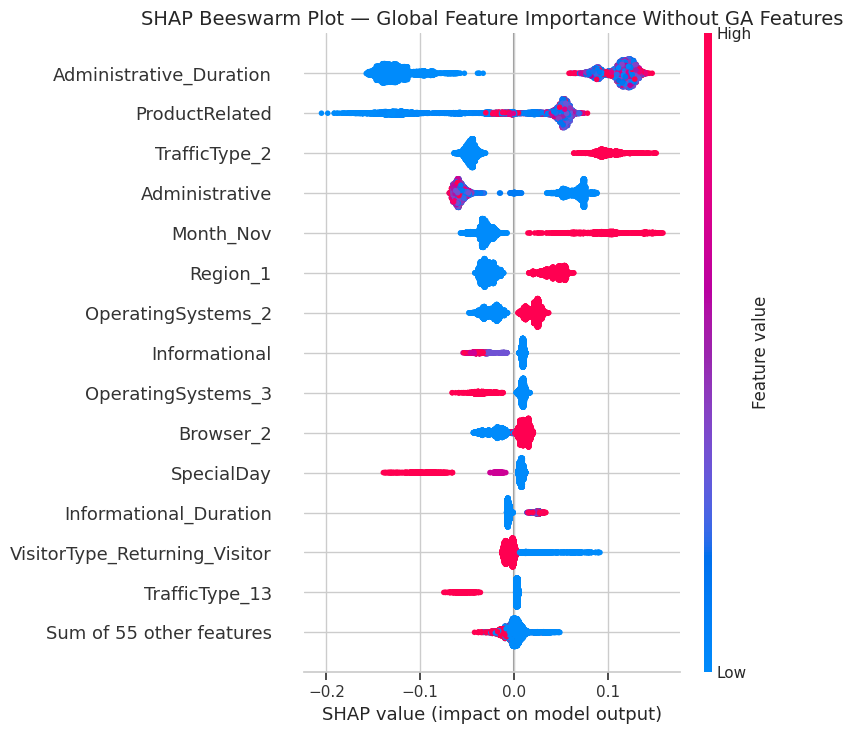

Beeswarm plot saved.


In [ ]:
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_obj_train, max_display=15, show=False)
plt.title("SHAP Beeswarm Plot — Global Feature Importance Without GA Features", fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DMML_Project/shap_beeswarm_noGA.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm plot saved.")

- The **bar plot** shows the mean absolute SHAP value per feature — a cleaner ranking of overall importance, without direction.

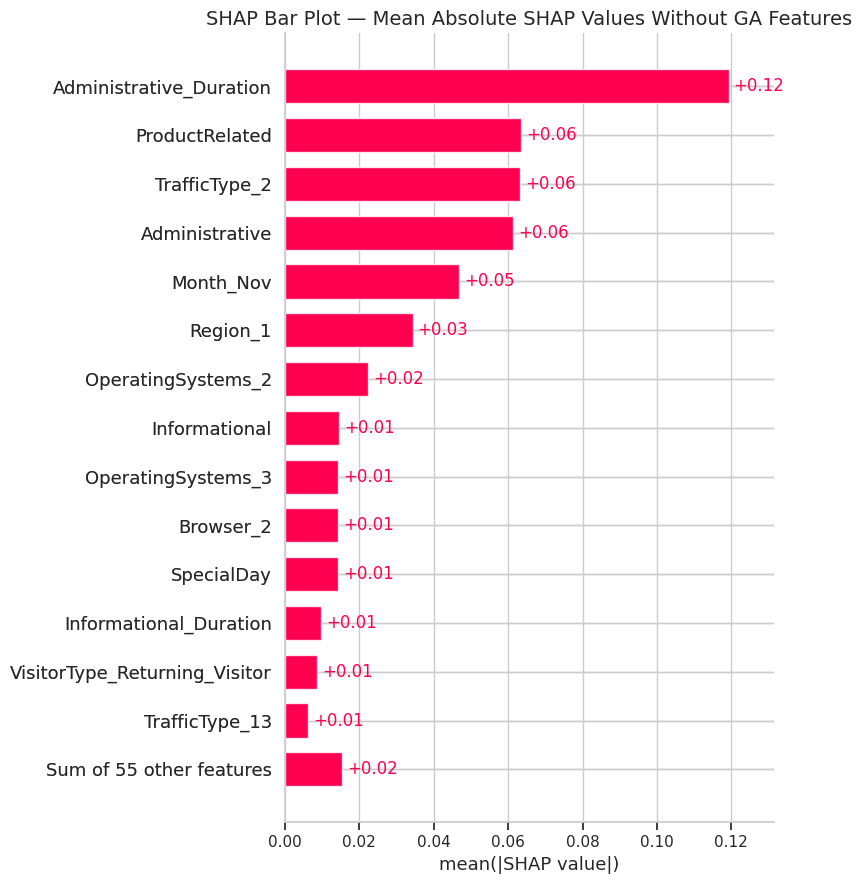

Bar plot saved.


In [ ]:
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_obj_train, max_display=15, show=False)
plt.title("SHAP Bar Plot — Mean Absolute SHAP Values Without GA Features", fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DMML_Project/shap_bar_noGA.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Bar plot saved.")

## 8.2 Local SHAP — Sample Selection from Test Set

To identify representative samples for the local SHAP analysis we select two cases from the held-out test set: a **True Positive**, a **False Negative**

**Note:** Samples are drawn from `X_test_noGA`, a 30% stratified
hold-out that was never seen by `final_model_noGA` during training (section 7.4b).


In [ ]:
# --- Predictions on the test set ---
y_pred_test  = final_model_noGA.named_steps['classifier'].predict(X_shap_test)
y_proba_test = final_model_noGA.named_steps['classifier'].predict_proba(X_shap_test)[:, 1]

rng = np.random.default_rng(42)
# True Positive: actual purchase, predicted purchase
tp_idx = tp_indices[rng.integers(len(tp_indices))]
# False Negative: actual purchase, predicted no purchase
fn_idx = fn_indices[rng.integers(len(fn_indices))]

print(f'True Positive  — index: {tp_idx}, P(purchase)={y_proba_test[tp_idx]:.4f}, True={y_test_noGA.values[tp_idx]}')
if fn_idx is not None:
    print(f'False Negative — index: {fn_idx}, P(purchase)={y_proba_test[fn_idx]:.4f}, True={y_test_noGA.values[fn_idx]}')
else:
    print('False Negative — none found in test set.')

True Positive  — index: 374, P(purchase)=0.7518, True=1
False Negative — index: 2967, P(purchase)=0.3826, True=1


--- TRUE POSITIVE ---
True label: 1 | Predicted: 1 | P(purchase): 0.7518


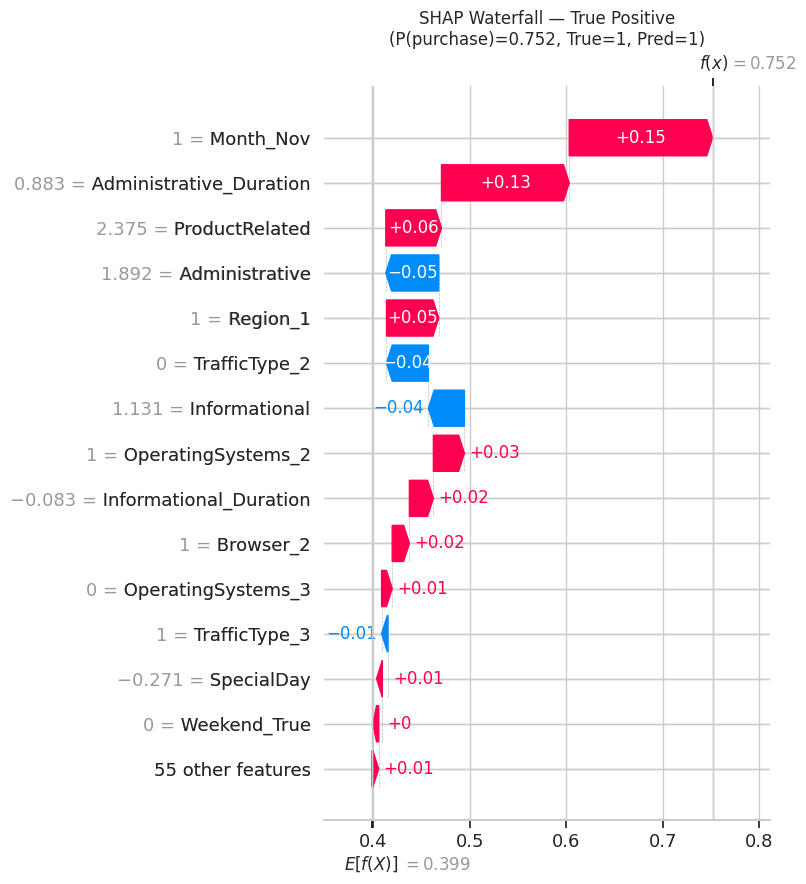

Waterfall TP saved.


In [ ]:
# --- Local SHAP: Waterfall Plot — True Positive ---
print(f'--- TRUE POSITIVE ---')
print(f'True label: {y_test_noGA.values[tp_idx]} | Predicted: {y_pred_test[tp_idx]} | P(purchase): {y_proba_test[tp_idx]:.4f}')

shap.plots.waterfall(shap_obj_test[tp_idx], max_display=15, show=False)
plt.title(
    f'SHAP Waterfall — True Positive\n'
    f'(P(purchase)={y_proba_test[tp_idx]:.3f}, True={y_test_noGA.values[tp_idx]}, Pred={y_pred_test[tp_idx]})',
    fontsize=12
)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DMML_Project/shap_waterfall_tp_noGA.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Waterfall TP saved.')

--- FALSE NEGATIVE ---
True label: 1 | Predicted: 0 | P(purchase): 0.3826


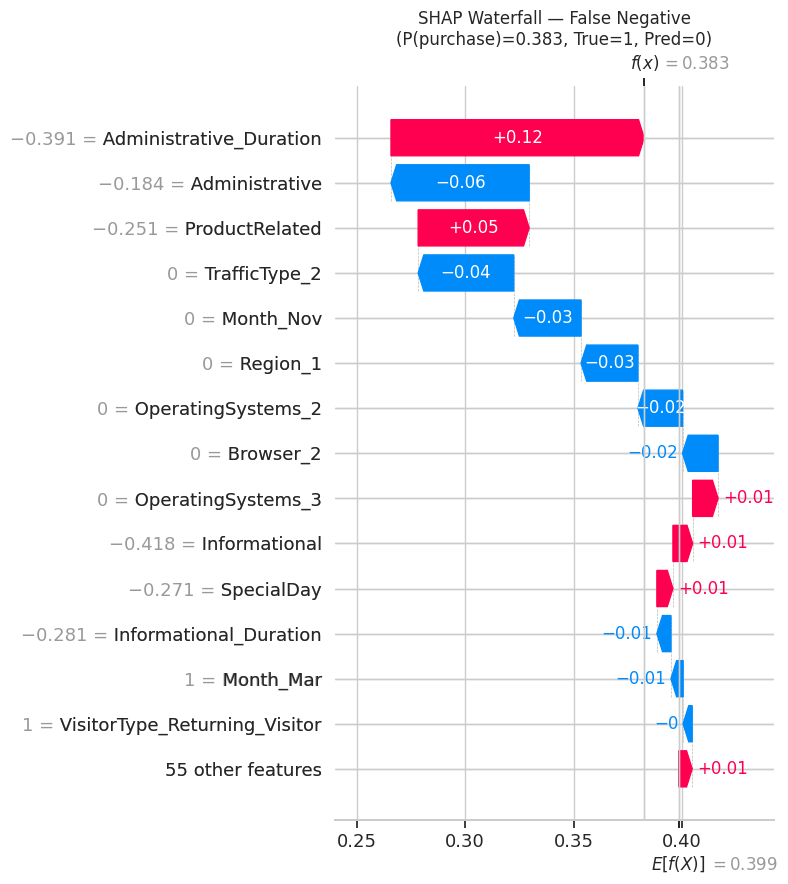

Waterfall FN saved.


In [ ]:
# --- Local SHAP: Waterfall Plot — False Negative ---
if fn_idx is None:
    print('No False Negative samples found in the test set.')
else:
    print(f'--- FALSE NEGATIVE ---')
    print(f'True label: {y_test_noGA.values[fn_idx]} | Predicted: {y_pred_test[fn_idx]} | P(purchase): {y_proba_test[fn_idx]:.4f}')

    shap.plots.waterfall(shap_obj_test[fn_idx], max_display=15, show=False)
    plt.title(
        f'SHAP Waterfall — False Negative\n'
        f'(P(purchase)={y_proba_test[fn_idx]:.3f}, True={y_test_noGA.values[fn_idx]}, Pred={y_pred_test[fn_idx]})',
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/DMML_Project/shap_waterfall_fn_noGA.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Waterfall FN saved.')